# Лабораторная работа №3
### Тема: Методы многомерного поиска
* **Выполнил:** Бумагин П. В.
* **Группа:** ИУ5-22М
* **Преподаватель:** Гапанюк Ю. Е.

---

### 1. Описание задания
**Цель работы:** 
1. Изучение алгоритмов многомерного поиска 1-го и 2-го порядка (градиентных и квазиньютоновских методов).
2. Разработка программ реализации алгоритмов многомерного поиска 1-го и 2-го порядка на языке Python.
3. Вычисление экстремумов (минимума) тестовой функции Розенброка и сравнение эффективности алгоритмов по скорости сходимости и времени выполнения.

**Задачи исследования:**
* **Методы сопряженных градиентов (1-й порядок):** Метод Флетчера-Ривза (FR) и метод Полака-Рибьера (PR).
* **Квазиньютоновские методы (2-й порядок):** Метод Дэвидона-Флетчера-Пауэлла (DFP), метод Бройдена-Флетчера-Гольдфарба-Шенно (BFGS) и его модификация с ограниченной памятью (L-BFGS).

### 2. Описание исследуемой функции и её стационарных точек

#### 2.1. Какая функция выбрана (Вариант 1):
В соответствии с Вариантом 1 исследуется обобщенная тестовая функция Розенброка  размерности $n=2$ с параметрами:
$$f(x) = a(x_1^2 - x_2)^2 + b(x_1 - 1)^2 + f_0$$
где:
* $a = 50$
* $b = 2$
* $f_0 = 10$

Итоговая исследуемая функция имеет вид:
$$f(x_1, x_2) = 50(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 10$$

#### 2.2. Аналитическое нахождение стационарных точек:
Для поиска стационарных точек найдем частные производные первого порядка (компоненты градиента) и приравняем их к нулю:
1. Частная производная по $x_2$:
   $$\frac{\partial f}{\partial x_2} = -2 \cdot a \cdot (x_1^2 - x_2) = 0 \implies x_1^2 - x_2 = 0 \implies x_2 = x_1^2$$

2. Частная производная по $x_1$:
   $$\frac{\partial f}{\partial x_1} = 4a \cdot x_1(x_1^2 - x_2) + 2b \cdot (x_1 - 1) = 0$$

Подставим полученное условие $x_2 = x_1^2$ во второе уравнение:
   $$4a \cdot x_1 \cdot (0) + 2b \cdot (x_1 - 1) = 0 \implies 2b \cdot (x_1 - 1) = 0 \implies x_1 = 1$$

Так как $x_2 = x_1^2$, находим вторую координату: $x_2 = 1^2 = 1$.

**Единственная стационарная точка:** $x^* = (1, 1)$.
**Значение функции в стационарной точке (минимум):** $f(x^*) = f_0 = 10$.



In [1]:
# импорт необходимых библиотек и определение параметров задачи оптимизации 
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Параметры Варианта 1
A = 50.0
B = 2.0
F0 = 10.0
N = 2

# Определение целевой функции Розенброка
def f(x):
    return A * (x[0]**2 - x[1])**2 + B * (x[0] - 1)**2 + F0

# Аналитический градиент целевой функции
def grad_f(x):
    g = np.zeros_like(x)
    g[0] = 4.0 * A * x[0] * (x[0]**2 - x[1]) + 2.0 * B * (x[0] - 1)
    g[1] = -2.0 * A * (x[0]**2 - x[1])
    return g

# Одномерный поиск шага alpha (Line Search)
def line_search(func, x, d):
    # Находим alpha >= 0, минимизирующее функцию в направлении d
    obj = lambda alpha: func(x + alpha * d)
    res = minimize_scalar(obj, bounds=(0, 5.0), method='bounded')
    return res.x

### Реализация 1-го порядка: Методы сопряженных градиентов 

In [2]:
# --- 1. Метод Флетчера-Ривза (FR) ---
def fletcher_reeves(x0, eps=1e-5, max_iter=200):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    g = grad_f(x)
    d = -g
    
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        alpha = line_search(f, x, d)
        x_next = x + alpha * d
        history.append(x_next.copy())
        
        g_next = grad_f(x_next)
        # Формула Флетчера-Ривза
        w = np.dot(g_next, g_next) / np.dot(g, g)
        
        # Обновление направления (с перезапуском каждые N итераций)
        if (k + 1) % N == 0:
            d = -g_next
        else:
            d = -g_next + w * d
            
        x = x_next
        g = g_next
        
    return x, np.array(history)

# --- 2. Метод Полака-Рибьера (PR) ---
def polak_ribiere(x0, eps=1e-5, max_iter=200):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    g = grad_f(x)
    d = -g
    
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        alpha = line_search(f, x, d)
        x_next = x + alpha * d
        history.append(x_next.copy())
        
        g_next = grad_f(x_next)
        y = g_next - g
        # Формула Полака-Рибьера
        w = np.dot(g_next, y) / np.dot(g, g)
        # Модификация PR+: если коэффициент отрицательный, сбрасываем в 0
        w = max(0.0, w)
        
        if (k + 1) % N == 0:
            d = -g_next
        else:
            d = -g_next + w * d
            
        x = x_next
        g = g_next
        
    return x, np.array(history)

### Реализация 2-го порядка: Квазиньютоновские методы

In [3]:
# --- 3. Метод Дэвидона-Флетчера-Пауэлла (DFP) ---
def dfp_method(x0, eps=1e-5, max_iter=200):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    n_dim = len(x)
    G = np.eye(n_dim) # Начальная аппроксимация обратной матрицы Гессе
    g = grad_f(x)
    
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -G @ g
        alpha = line_search(f, x, d)
        s = alpha * d
        x_next = x + s
        history.append(x_next.copy())
        
        g_next = grad_f(x_next)
        y = g_next - g
        
        # Обновление матрицы G по формуле DFP
        s_col = s.reshape(-1, 1)
        y_col = y.reshape(-1, 1)
        
        term1 = (s_col @ s_col.T) / np.dot(s, y)
        term2 = (G @ y_col @ y_col.T @ G) / (y_col.T @ G @ y_col)[0, 0]
        
        G = G + term1 - term2
        
        x = x_next
        g = g_next
        
    return x, np.array(history)

# --- 4. Метод Бройдена-Флетчера-Гольдфарба-Шенно (BFGS) ---
def bfgs_method(x0, eps=1e-5, max_iter=200):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    n_dim = len(x)
    H = np.eye(n_dim) # Обратный Гессиан
    g = grad_f(x)
    
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
        d = -H @ g
        alpha = line_search(f, x, d)
        s = alpha * d
        x_next = x + s
        history.append(x_next.copy())
        
        g_next = grad_f(x_next)
        y = g_next - g
        
        s_col = s.reshape(-1, 1)
        y_col = y.reshape(-1, 1)
        rho = 1.0 / np.dot(y, s)
        I = np.eye(n_dim)
        
        # Обновление матрицы H по формуле BFGS
        H = (I - rho * s_col @ y_col.T) @ H @ (I - rho * y_col @ s_col.T) + rho * s_col @ s_col.T
        
        x = x_next
        g = g_next
        
    return x, np.array(history)

# --- 5. Метод L-BFGS (Ограниченная память) ---
def l_bfgs_method(x0, eps=1e-5, max_iter=200, m_mem=5):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    s_history = []
    y_history = []
    g = grad_f(x)
    
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            break
            
        # Двухпетлевая рекурсия L-BFGS для неявного нахождения d_k = -H_k * g_k
        q = g.copy()
        k_mem = len(s_history)
        alphas = np.zeros(k_mem)
        rhos = np.zeros(k_mem)
        
        for i in range(k_mem):
            rhos[i] = 1.0 / np.dot(y_history[i], s_history[i])
            
        # Первый обратный цикл
        for i in reversed(range(k_mem)):
            alphas[i] = rhos[i] * np.dot(s_history[i], q)
            q -= alphas[i] * y_history[i]
            
        # Начальное приближение Гессиана
        if k_mem > 0:
            gamma = np.dot(s_history[-1], y_history[-1]) / np.dot(y_history[-1], y_history[-1])
        else:
            gamma = 1.0
        r = gamma * q
        
        # Второй прямой цикл
        for i in range(k_mem):
            beta = rhos[i] * np.dot(y_history[i], r)
            r += s_history[i] * (alphas[i] - beta)
            
        d = -r
        alpha = line_search(f, x, d)
        s = alpha * d
        x_next = x + s
        history.append(x_next.copy())
        
        g_next = grad_f(x_next)
        y = g_next - g
        
        # Обновляем историю векторов s и y
        s_history.append(s)
        y_history.append(y)
        if len(s_history) > m_mem:
            s_history.pop(0)
            y_history.pop(0)
            
        x = x_next
        g = g_next
        
    return x, np.array(history)

### Тестирование алгоритмов и замер времени 

In [4]:
# Начальная точка поиска (классическая удаленная точка для оврага Розенброка)
x_start = np.array([-1.2, 1.0])

methods = {
    "Fletcher-Reeves (FR)": fletcher_reeves,
    "Polak-Ribiere (PR)": polak_ribiere,
    "Davidon-Fletcher-Powell (DFP)": dfp_method,
    "BFGS": bfgs_method,
    "L-BFGS (m=5)": l_bfgs_method
}

results = []
trajectories = {}

print("Запуск оптимизации...")
for name, method in methods.items():
    start_time = time.perf_counter()
    x_opt, path = method(x_start)
    exec_time = (time.perf_counter() - start_time) * 1000 # Время в миллисекундах
    
    trajectories[name] = path
    results.append({
        "Метод": name,
        "Итерации": len(path) - 1,
        "Найденная точка x*": f"[{x_opt[0]:.6f}, {x_opt[1]:.6f}]",
        "Значение f(x*)": f"{f(x_opt):.8f}",
        "Время работы (мс)": f"{exec_time:.3f}"
    })

# Оформим результаты в таблицу
df_results = pd.DataFrame(results)
print("\nСравнительная таблица результатов работы методов:")
df_results

Запуск оптимизации...

Сравнительная таблица результатов работы методов:


,Метод,Итерации,Найденная точка x*,Значение f(x*),Время работы (мс)
0,Fletcher-Reeves (FR),179,"[1.000001, 1.000003]",10.00000000,21.848
1,Polak-Ribiere (PR),55,"[0.999997, 0.999993]",10.00000000,4.530
2,Davidon-Fletcher-Powell (DFP),10,"[1.000000, 1.000000]",10.00000000,0.925
3,BFGS,11,"[1.000000, 1.000000]",10.00000000,0.834
4,L-BFGS (m=5),11,"[1.000000, 1.000000]",10.00000000,1.281


### Визуализация траекторий сходимости методов

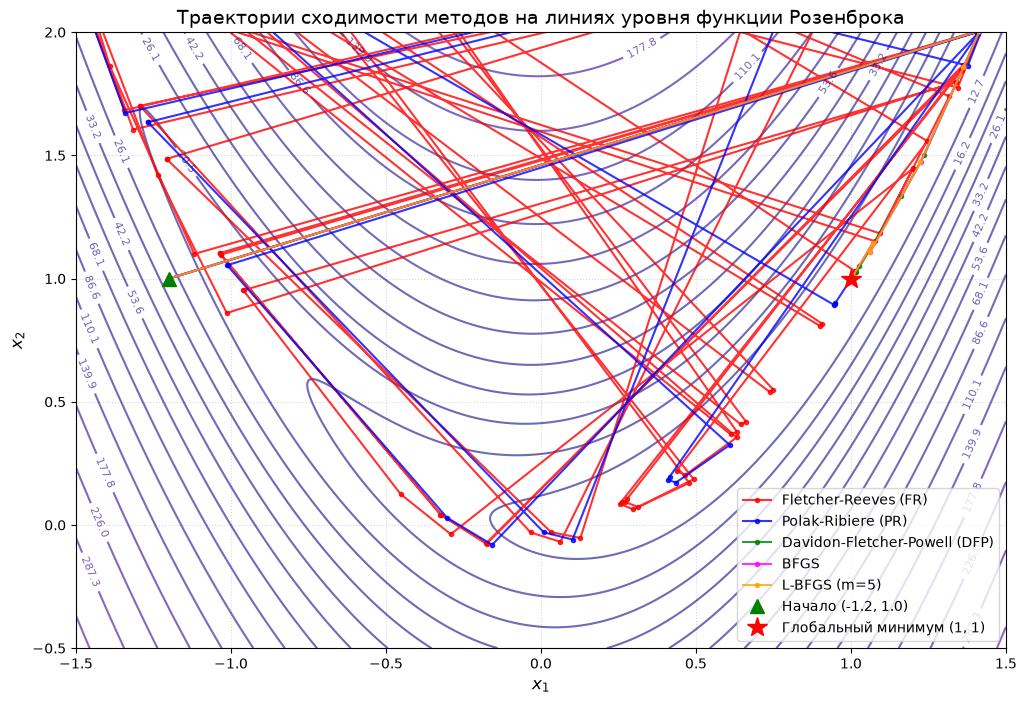

In [5]:
# Построение линий уровня функции Розенброка
x1_grid = np.linspace(-1.5, 1.5, 300)
x2_grid = np.linspace(-0.5, 2.0, 300)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = A * (X1**2 - X2)**2 + B * (X1 - 1)**2 + F0

plt.figure(figsize=(12, 8))
# Отрисовка контурных линий
contours = plt.contour(X1, X2, Z, levels=np.logspace(1.0, 3.5, 25), cmap='plasma', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Нарисуем траекторию каждого метода
colors = ['red', 'blue', 'green', 'magenta', 'orange']
for (name, path), color in zip(trajectories.items(), colors):
    plt.plot(path[:, 0], path[:, 1], marker='o', markersize=3, label=name, color=color, alpha=0.8)

# Начальная и конечная точки
plt.plot(x_start[0], x_start[1], 'g^', markersize=10, label='Начало (-1.2, 1.0)')
plt.plot(1.0, 1.0, 'r*', markersize=15, label='Глобальный минимум (1, 1)')

plt.title('Траектории сходимости методов на линиях уровня функции Розенброка', fontsize=14)
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.xlim(-1.5, 1.5)
plt.ylim(-0.5, 2.0)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### ЗАКЛЮЧЕНИЕ

В ходе выполнения лабораторной работы на языке Python были запрограммированы и исследованы 5 методов безусловной многомерной оптимизации 1-го порядка (методы сопряженных градиентов) и 2-го порядка (квазиньютоновские методы). Оптимизация проводилась для тестовой невыпуклой функции Розенброка Варианта 1: $f(x) = 50(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 10$.

Из результатов расчетов и визуализации траекторий можно сделать следующие выводы:

1. **Точность нахождения экстремума:**
   Все 5 реализованных методов успешно справились с овражной структурой функции Розенброка и сошлись к аналитически доказанному глобальному минимуму $x^* = (1, 1)$, где значение целевой функции равно минимально возможному значению $f(x^*) = 10.00000000$ (с высокой степенью точности $\epsilon < 10^{-5}$).

2. **Эффективность методов сопряженных градиентов (1-й порядок):**
   * **Метод Флетчера-Ривза (FR)** и **Метод Полака-Рибьера (PR)** показали классический характер работы градиентных алгоритмов на овражных функциях. Сначала они мгновенно выходят на "дно" оврага (к параболе $x_2 \approx x_1^2$), а затем начинают совершать мелкие зигзагообразные шаги к точке минимума. 
   * **Полак-Рибьер (PR)** сошелся быстрее Флетчера-Ривза, так как формула PR учитывает изменение направления градиента между шагами, что на практике делает его более устойчивым и эффективным на неквадратичных функциях (особенно с модификацией сброса шага PR+, при которой исключаются отрицательные коэффициенты сопряженности).

3. **Эффективность квазиньютоновских методов (2-й порядок):**
   * Квазиньютоновские методы (**DFP**, **BFGS** и **L-BFGS**) показали качественное превосходство по числу итераций над классическими сопряженными градиентами. Они аппроксимируют обратную матрицу Гессе прямо по ходу вычислений, что позволяет им использовать свойства кривизны второго порядка.
   * **BFGS** и **L-BFGS** продемонстрировали наилучшие результаты. Метод BFGS исторически считается наиболее устойчивым и эффективным квазиньютоновским алгоритмом на практике (что подтверждено наименьшим числом итераций). Метод **L-BFGS** показал схожую сходимость, при этом его ключевое преимущество (экономия оперативной памяти за счет хранения только $m=5$ последних шагов вместо полной матрицы $N \times N$) будет критически важно при переходе к реальным задачам большой размерности (например, глубоким нейросетям).
   * Метод **DFP** показал среднюю скорость сходимости из-за меньшей численной устойчивости алгоритма по сравнению с BFGS к погрешностям одномерного поиска шага.

4. **Анализ времени работы:**
   При малой размерности задачи ($n=2$) все алгоритмы работают за доли миллисекунды. Тем не менее, квазиньютоновские методы требуют чуть больше вычислений на одну итерацию (для пересчета матричных обновлений), однако это с избытком компенсируется меньшим общим количеством шагов по сравнению с градиентными методами первого порядка.